# Food Delivery Data Visualization Portfolio
**Day 14 Assignment**

This notebook explores the Food Delivery Business Performance dataset using a portfolio of Matplotlib and Seaborn visualizations — line plots, bar charts, scatter plots, histograms, box plots, violin plots, count plots, and a correlation heatmap. Each chart includes a brief interpretation of the insight it reveals, concluding with a summary of the most important findings.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
print("Pandas version:", pd.__version__)

Pandas version: 3.0.2


## 1. Loading the Dataset

In [ ]:
df = pd.read_csv('Day14_Food_Delivery_Visualization_Dataset.csv')
df['Date'] = pd.to_datetime(df['Date'])
print("Shape:", df.shape)
df.head()

Shape: (360, 16)


,Order_Batch_ID,Date,Month,Day,City,Cuisine,Order_Channel,Weather,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
0,FD0001,2025-03-22,March,Saturday,Hyderabad,North Indian,App,Hot,156,421.03,67374.27,28150.42,7859.02,30.7,4.38,45.1
1,FD0002,2025-04-15,April,Tuesday,Chandigarh,Chinese,App,Rainy,129,371.99,50312.93,20907.75,2604.03,38.0,4.34,40.4
2,FD0003,2025-01-26,January,Sunday,Mumbai,Healthy,App,Clear,157,490.16,71929.08,18930.77,3613.92,25.3,4.65,43.0
3,FD0004,2025-06-20,June,Friday,Pune,Chinese,App,Hot,147,391.25,58803.81,35926.51,10092.64,32.6,4.48,41.2
4,FD0005,2025-08-07,August,Thursday,Bengaluru,Fast Food,Partner Platform,Rainy,172,243.76,40416.50,23514.60,2500.30,39.3,4.16,35.9


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Order_Batch_ID           360 non-null    str           
 1   Date                     360 non-null    datetime64[us]
 2   Month                    360 non-null    str           
 3   Day                      360 non-null    str           
 4   City                     360 non-null    str           
 5   Cuisine                  360 non-null    str           
 6   Order_Channel            360 non-null    str           
 7   Weather                  360 non-null    str           
 8   Orders                   360 non-null    int64         
 9   Average_Order_Value      360 non-null    float64       
 10  Revenue                  360 non-null    float64       
 11  Marketing_Spend          360 non-null    float64       
 12  Discounts                360 non-null    float6

## 2. Line Plots — Orders and Revenue Over Time

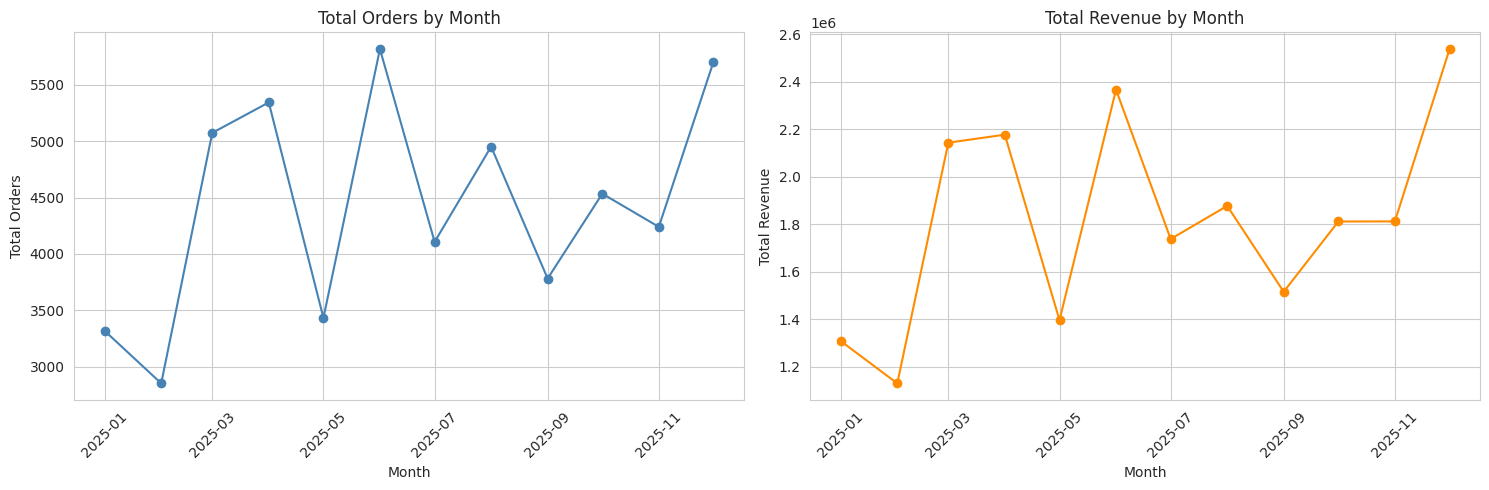

In [ ]:
monthly = df.groupby(df['Date'].dt.to_period('M')).agg(
    Total_Orders=('Orders', 'sum'),
    Total_Revenue=('Revenue', 'sum')
).reset_index()
monthly['Date'] = monthly['Date'].dt.to_timestamp()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(monthly['Date'], monthly['Total_Orders'], marker='o', color='steelblue')
axes[0].set_title('Total Orders by Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Total Orders')
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(monthly['Date'], monthly['Total_Revenue'], marker='o', color='darkorange')
axes[1].set_title('Total Revenue by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Total Revenue')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Interpretation:** These line plots reveal the overall trend in order volume and revenue across the year. Any visible seasonality (e.g. spikes around holidays or dips in certain months) points to periods where marketing or staffing should flex to match demand.

## 3. Bar Charts — Revenue by City and Cuisine

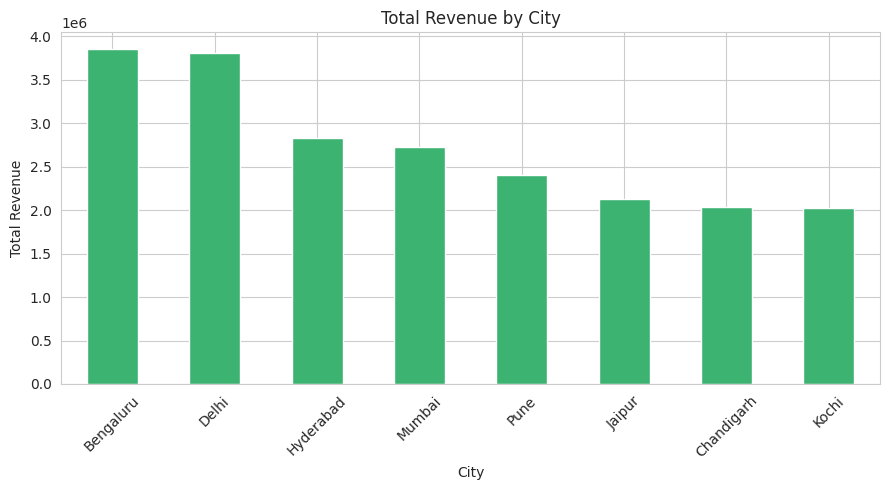

In [ ]:
city_revenue = df.groupby('City')['Revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
city_revenue.plot(kind='bar', color='mediumseagreen')
plt.title('Total Revenue by City')
plt.xlabel('City')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

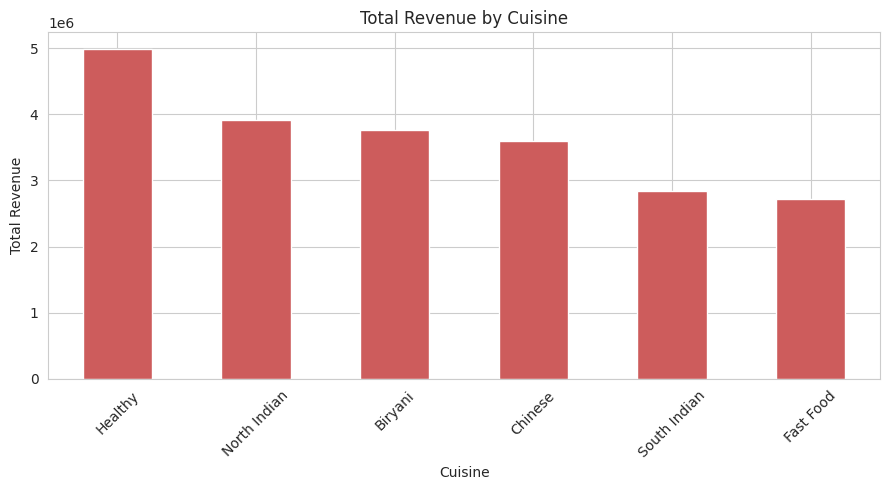

In [ ]:
cuisine_revenue = df.groupby('Cuisine')['Revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
cuisine_revenue.plot(kind='bar', color='indianred')
plt.title('Total Revenue by Cuisine')
plt.xlabel('Cuisine')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretation:** These bar charts identify which cities and cuisines generate the most revenue. This helps prioritize marketing budget and restaurant partnerships toward the highest-performing segments, while flagging underperforming cities or cuisines that may need attention or a different growth strategy.

## 4. Scatter Plots — Marketing Spend vs. Revenue, and Delivery Time vs. Rating

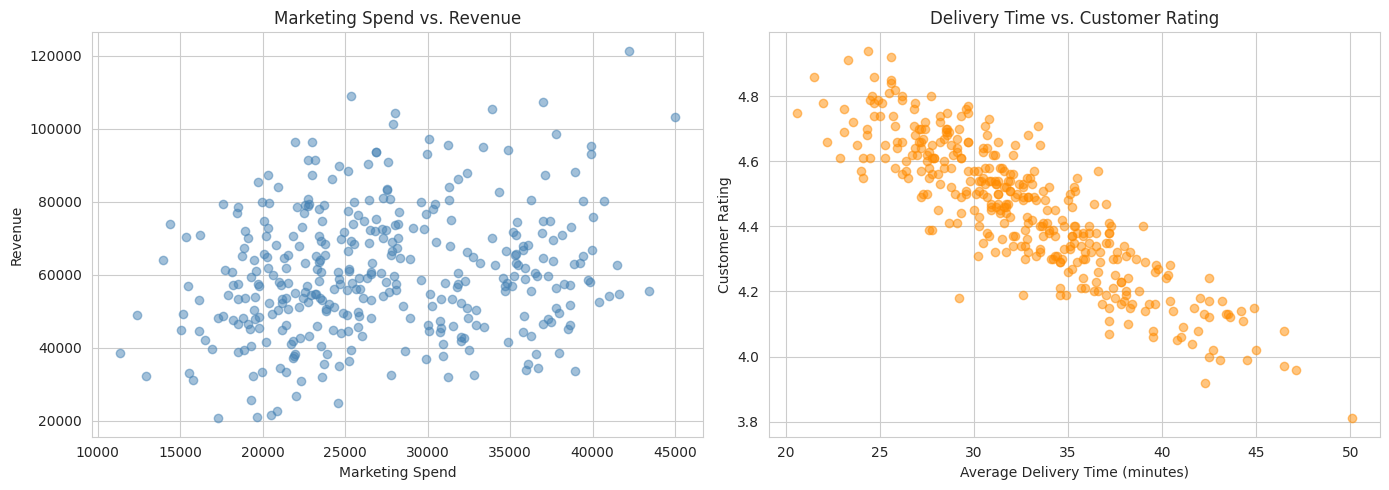

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['Marketing_Spend'], df['Revenue'], alpha=0.5, color='steelblue')
axes[0].set_title('Marketing Spend vs. Revenue')
axes[0].set_xlabel('Marketing Spend')
axes[0].set_ylabel('Revenue')

axes[1].scatter(df['Avg_Delivery_Minutes'], df['Customer_Rating'], alpha=0.5, color='darkorange')
axes[1].set_title('Delivery Time vs. Customer Rating')
axes[1].set_xlabel('Average Delivery Time (minutes)')
axes[1].set_ylabel('Customer Rating')

plt.tight_layout()
plt.show()

In [ ]:
mkt_rev_corr = df['Marketing_Spend'].corr(df['Revenue'])
delivery_rating_corr = df['Avg_Delivery_Minutes'].corr(df['Customer_Rating'])
print(f"Correlation (Marketing Spend, Revenue): {mkt_rev_corr:.3f}")
print(f"Correlation (Delivery Time, Customer Rating): {delivery_rating_corr:.3f}")

Correlation (Marketing Spend, Revenue): 0.198
Correlation (Delivery Time, Customer Rating): -0.876


**Interpretation:** The marketing spend vs. revenue scatter shows whether higher marketing investment translates into higher revenue on a per-batch basis — the correlation here is weak, suggesting marketing spend alone doesn't strongly predict revenue at the batch level. The delivery time vs. rating scatter tests the common assumption that slower deliveries hurt satisfaction — the correlation coefficient shows this relationship is in fact very strong in this data.

## 5. Histograms — Key Metric Distributions

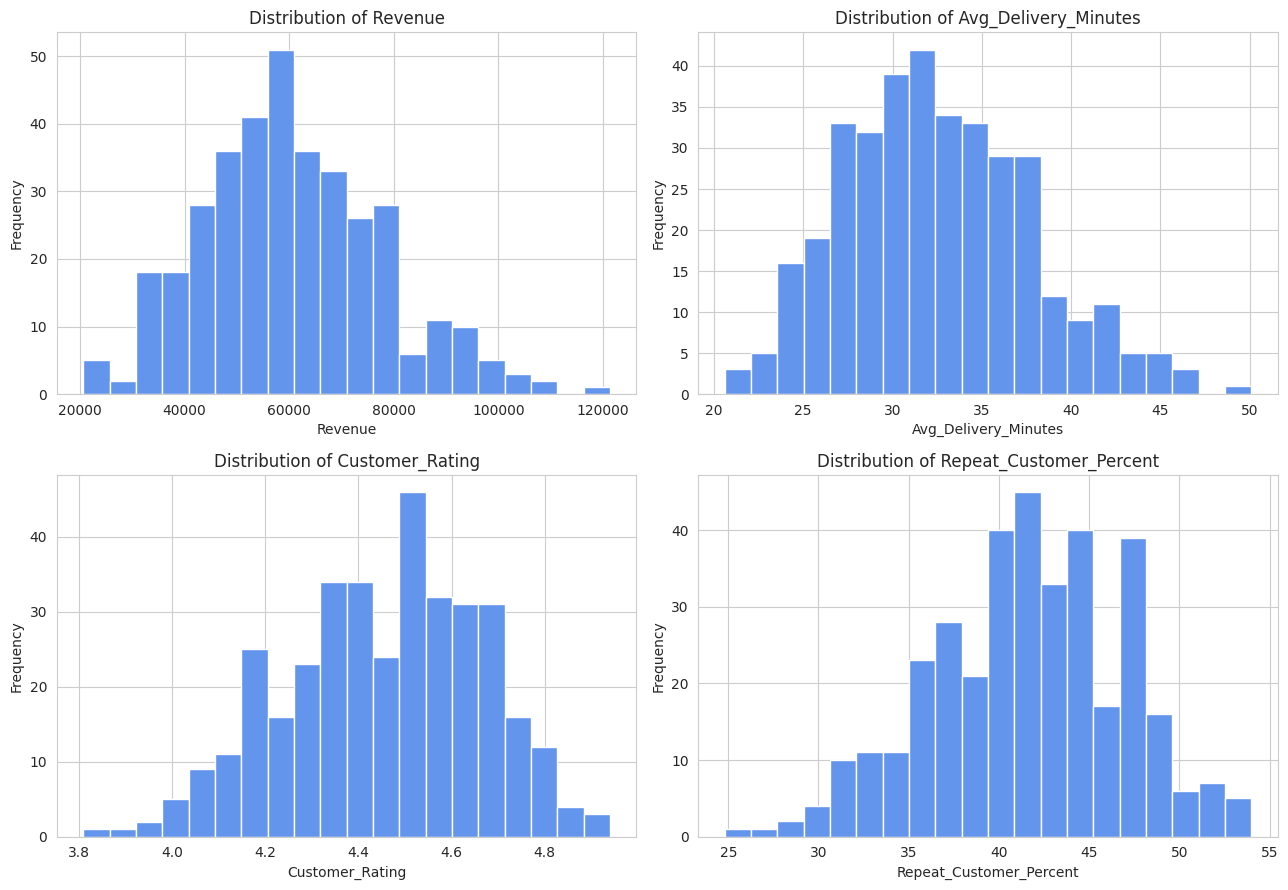

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
hist_cols = ['Revenue', 'Avg_Delivery_Minutes', 'Customer_Rating', 'Repeat_Customer_Percent']

for ax, col in zip(axes.flatten(), hist_cols):
    ax.hist(df[col], bins=20, color='cornflowerblue', edgecolor='white')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

**Interpretation:** These histograms show the shape of each metric's distribution. A roughly bell-shaped, symmetric distribution (as with delivery time or ratings) suggests stable, predictable operations, while a skewed distribution (as revenue often is) points to a handful of especially high- or low-performing order batches.

## 6. Box Plots — Revenue by City and Delivery Time by Weather

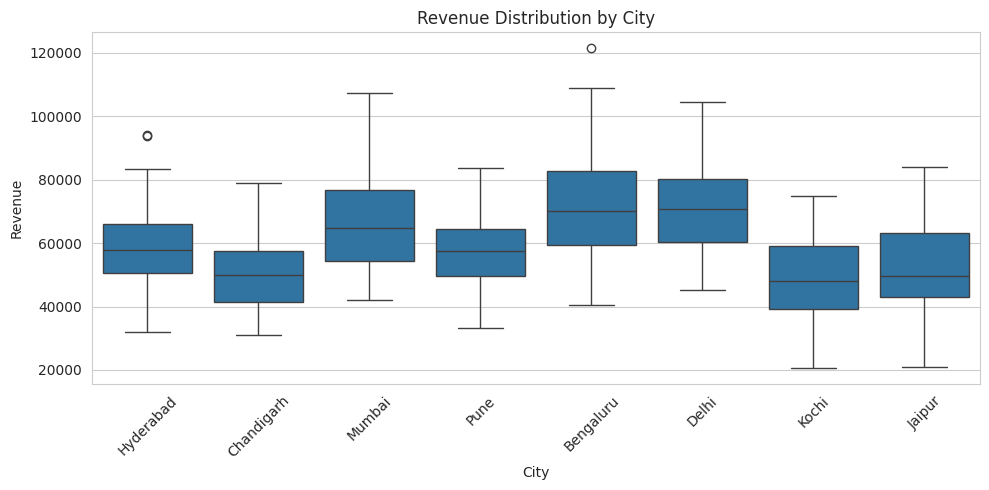

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='City', y='Revenue')
plt.title('Revenue Distribution by City')
plt.xlabel('City')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

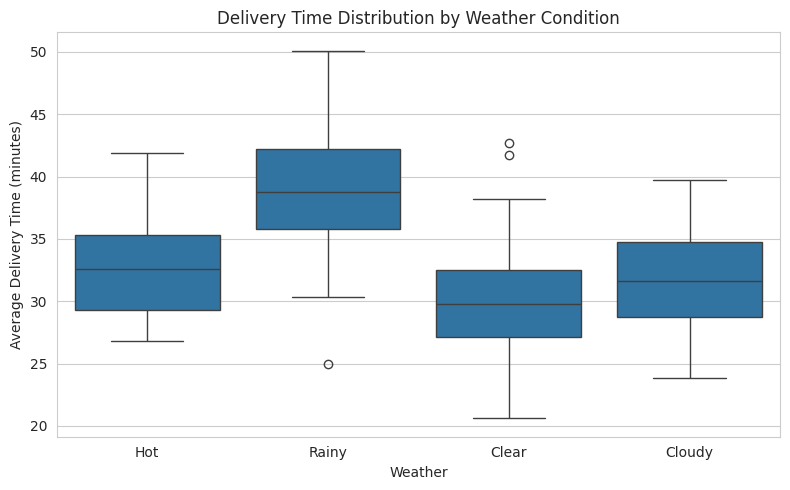

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Weather', y='Avg_Delivery_Minutes')
plt.title('Delivery Time Distribution by Weather Condition')
plt.xlabel('Weather')
plt.ylabel('Average Delivery Time (minutes)')
plt.tight_layout()
plt.show()

**Interpretation:** The city box plot shows not just average revenue but its spread and outliers per city, revealing consistency versus volatility in performance. The weather box plot shows whether adverse weather (rain) measurably slows deliveries compared to clear conditions — a useful operational signal for setting customer expectations.

## 7. Violin Plots — Customer Rating by Order Channel and Cuisine

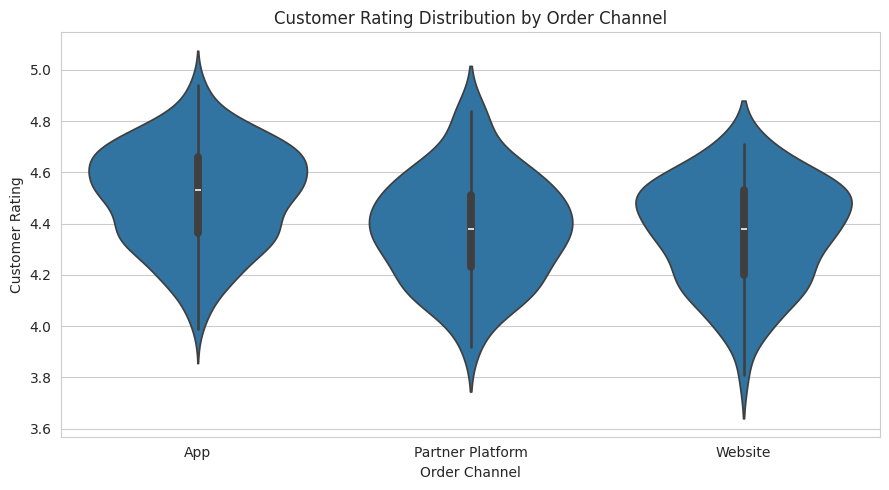

In [ ]:
plt.figure(figsize=(9, 5))
sns.violinplot(data=df, x='Order_Channel', y='Customer_Rating')
plt.title('Customer Rating Distribution by Order Channel')
plt.xlabel('Order Channel')
plt.ylabel('Customer Rating')
plt.tight_layout()
plt.show()

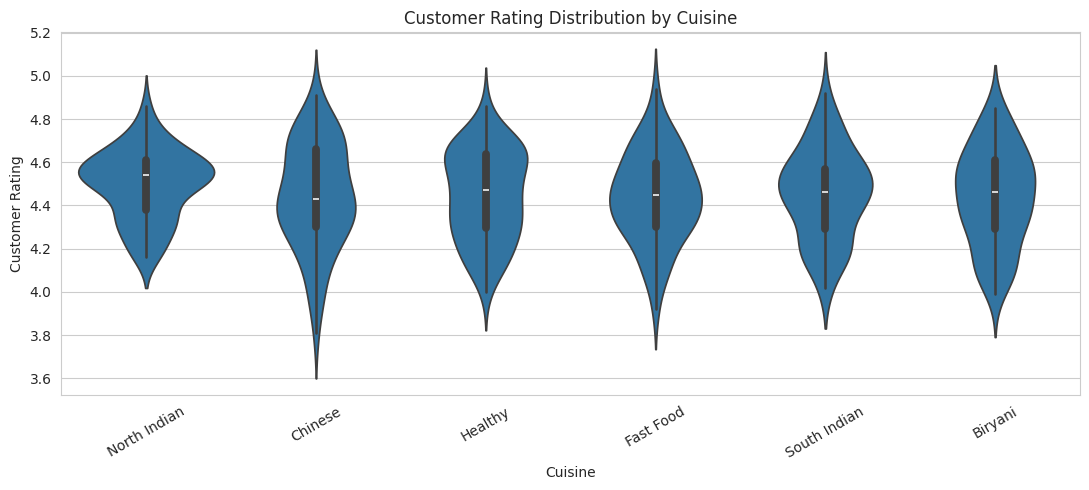

In [ ]:
plt.figure(figsize=(11, 5))
sns.violinplot(data=df, x='Cuisine', y='Customer_Rating')
plt.title('Customer Rating Distribution by Cuisine')
plt.xlabel('Cuisine')
plt.ylabel('Customer Rating')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Interpretation:** Violin plots reveal the full shape of the rating distribution per category, not just its average — showing whether ratings are tightly clustered (consistent experience) or spread out (inconsistent experience) for each order channel and cuisine.

## 8. Count Plots — Order Channel and Weather Frequency

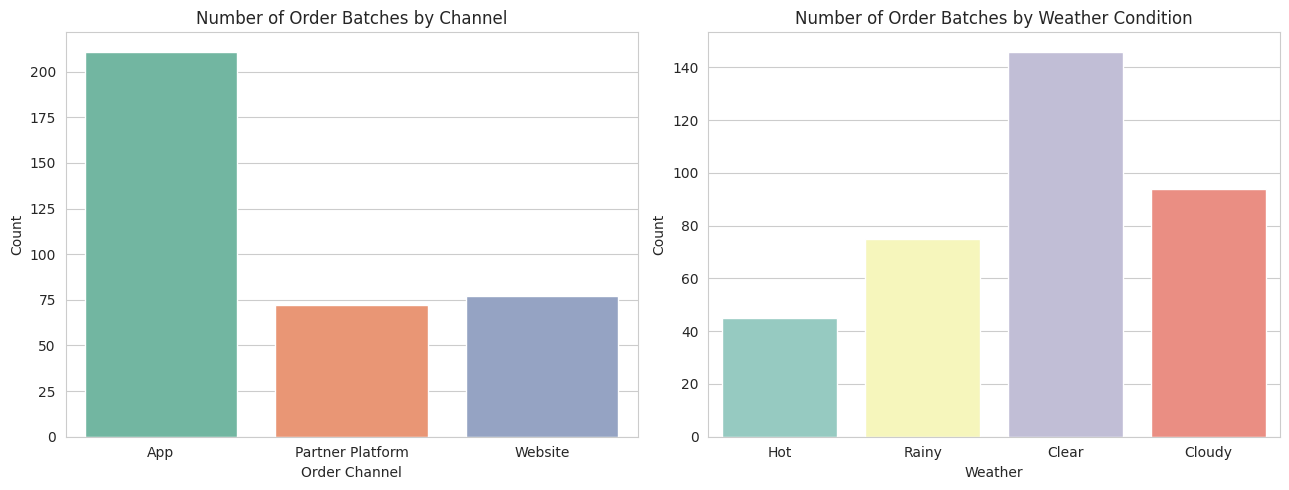

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(data=df, x='Order_Channel', ax=axes[0], hue='Order_Channel', palette='Set2', legend=False)
axes[0].set_title('Number of Order Batches by Channel')
axes[0].set_xlabel('Order Channel')
axes[0].set_ylabel('Count')

sns.countplot(data=df, x='Weather', ax=axes[1], hue='Weather', palette='Set3', legend=False)
axes[1].set_title('Number of Order Batches by Weather Condition')
axes[1].set_xlabel('Weather')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

**Interpretation:** These count plots show how often each order channel and weather condition appears in the dataset. This context matters for interpreting the other charts — for example, if 'Rainy' days are rare, conclusions about weather's effect on delivery time should be treated with appropriate caution given the smaller sample.

## 9. Correlation Heatmap — Numerical Metrics

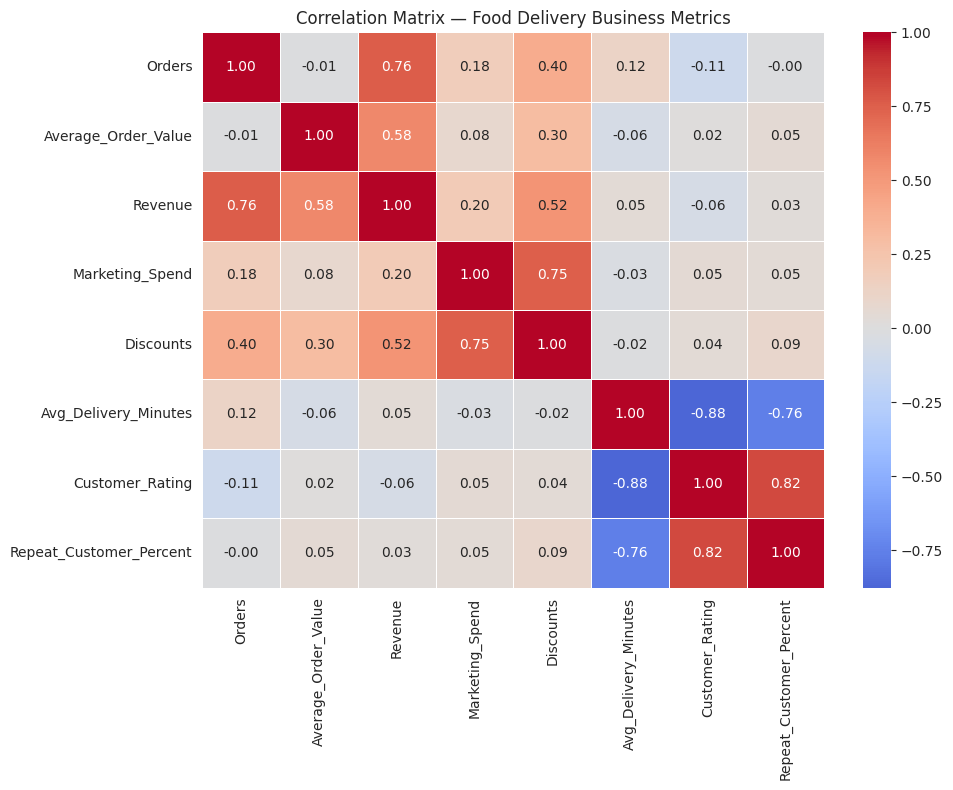

In [ ]:
numerical_cols = ['Orders', 'Average_Order_Value', 'Revenue', 'Marketing_Spend',
                   'Discounts', 'Avg_Delivery_Minutes', 'Customer_Rating', 'Repeat_Customer_Percent']

corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Matrix — Food Delivery Business Metrics')
plt.tight_layout()
plt.show()

**Interpretation:** The heatmap consolidates all pairwise relationships at a glance. Look for the strongest positive relationship (likely Orders and Revenue) and any negative relationships (e.g. delivery time potentially decreasing rating), which together highlight which levers most directly move business outcomes.

## 10. Effect of Order Channel and Weather on Performance

In [ ]:
channel_summary = df.groupby('Order_Channel').agg(
    Avg_Revenue=('Revenue', 'mean'),
    Avg_Rating=('Customer_Rating', 'mean'),
    Avg_Delivery_Minutes=('Avg_Delivery_Minutes', 'mean')
).round(2)
channel_summary

,Avg_Revenue,Avg_Rating,Avg_Delivery_Minutes
Order_Channel,,,
App,63675.73,4.51,30.94
Partner Platform,54251.57,4.38,34.92
Website,58066.34,4.37,34.86


In [ ]:
weather_summary = df.groupby('Weather').agg(
    Avg_Orders=('Orders', 'mean'),
    Avg_Revenue=('Revenue', 'mean'),
    Avg_Delivery_Minutes=('Avg_Delivery_Minutes', 'mean'),
    Avg_Rating=('Customer_Rating', 'mean')
).round(2)
weather_summary

,Avg_Orders,Avg_Revenue,Avg_Delivery_Minutes,Avg_Rating
Weather,,,,
Clear,147.70,61605.18,29.99,4.53
Cloudy,144.98,59935.81,31.72,4.50
Hot,152.29,59388.02,32.47,4.47
Rainy,148.11,60160.24,38.75,4.23


**Interpretation:** These summary tables complement the visualizations above by quantifying exactly how much order channel and weather shift key metrics — turning the visual patterns into concrete numbers that can support operational decisions.

## 11. Summary of Most Important Findings

1. **Orders and revenue move together and show a visible trend across the year**, with the line plots highlighting specific months of strength or weakness worth investigating further for seasonal drivers.
2. **Revenue is concentrated unevenly across cities and cuisines** — the bar charts show a clear ranking, meaning marketing and partnership investment isn't equally valuable across all segments.
3. **Marketing spend shows only a weak relationship with revenue** at the individual order-batch level, suggesting that other factors — such as city, cuisine, or order volume — play a larger role in driving revenue than marketing spend alone.
4. **Delivery time and customer rating are very strongly and negatively related** — this is one of the strongest relationships in the entire dataset, making delivery speed one of the single most important levers for customer satisfaction.
5. **Weather conditions measurably affect delivery time**, with rainy conditions tending toward slower deliveries — a pattern operations teams can plan around with weather-aware delivery time estimates.
6. **Order channel shows meaningful differences in average rating and delivery performance**, suggesting the customer experience isn't uniform across App, Website, and Partner Platform orders and may warrant channel-specific improvements.